# Eksperimen Preprocessing - Insurance Cost Prediction
**Nama:** Ari Setiawan
**Dataset:** Insurance Cost Prediction
**Tujuan:** Melakukan eksplorasi dan preprocessing data sebelum pelatihan model

## 1. Import Library

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from joblib import dump
import os
import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimport!')

Library berhasil diimport!


## 2. Data Loading

In [5]:
df = pd.read_csv('insurance_raw.csv')
print(f'Shape dataset: {df.shape}')
df.head()

Shape dataset: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
print('Informasi Dataset:')
df.info()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## 3. Exploratory Data Analysis (EDA)

In [7]:
print('\nMissing Values:')
print(df.isnull().sum())


Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


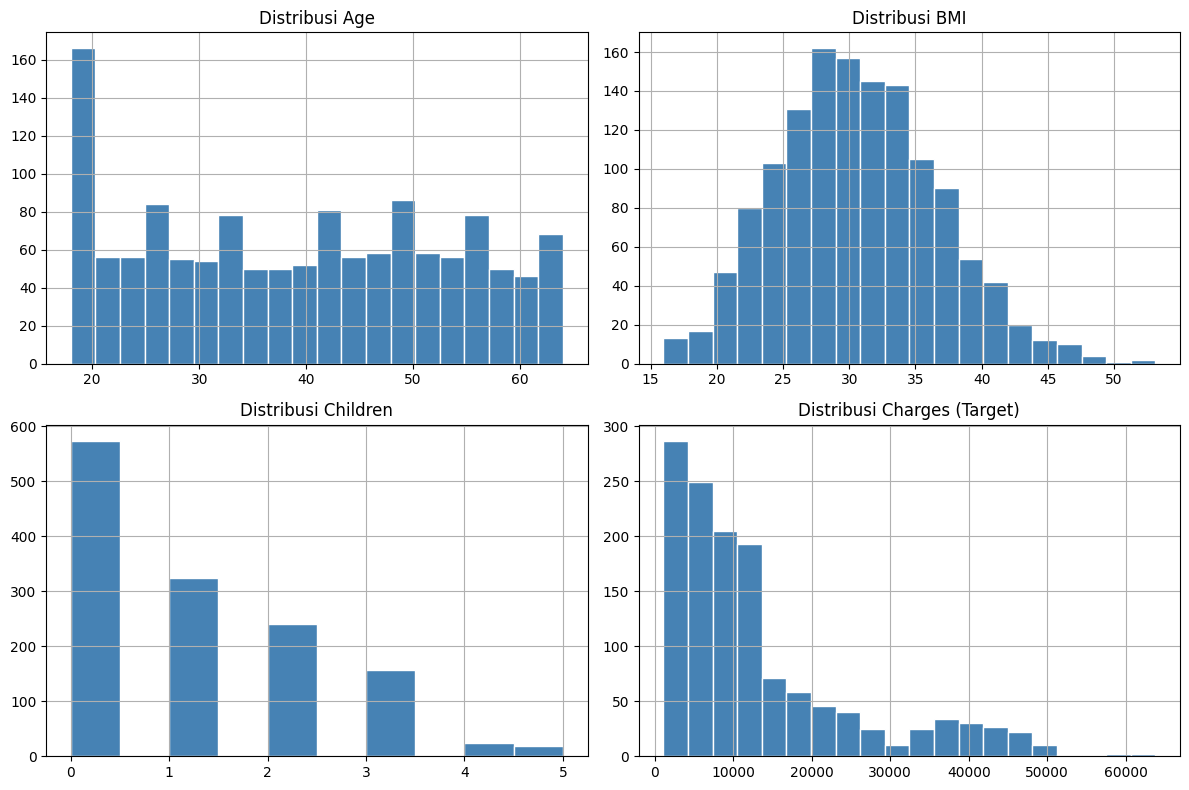

In [9]:
# Distribusi kolom numerik (visualisasi distribusi)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
df['age'].hist(ax=axes[0,0], bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribusi Age')
df['bmi'].hist(ax=axes[0,1], bins=20, color='steelblue', edgecolor='white')
axes[0,1].set_title('Distribusi BMI')
df['children'].hist(ax=axes[1,0], color='steelblue', edgecolor='white')
axes[1,0].set_title('Distribusi Children')
df['charges'].hist(ax=axes[1,1], bins=20, color='steelblue', edgecolor='white')
axes[1,1].set_title('Distribusi Charges (Target)')
plt.tight_layout()
plt.show()

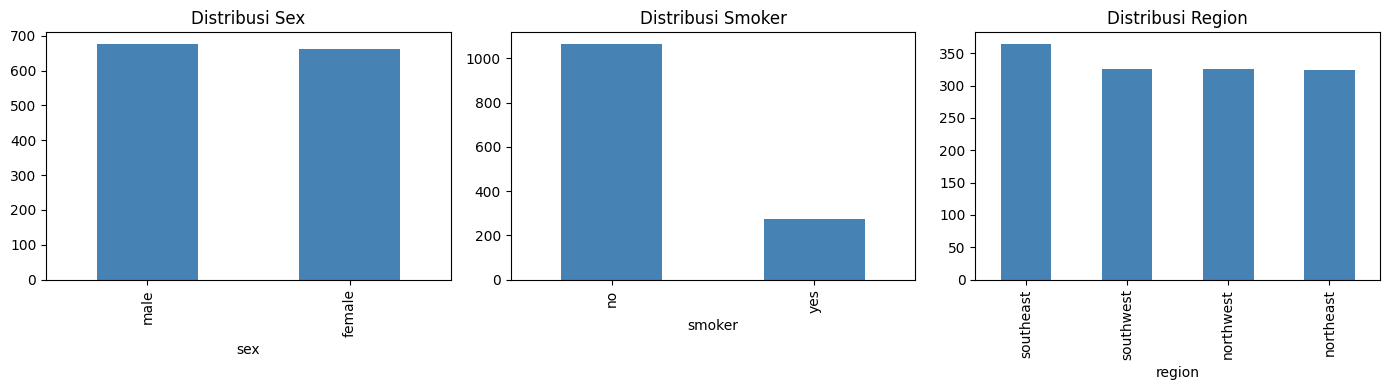

In [10]:
# Distribusi kolom kategorikal (visualisasi kategorikal)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df['sex'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribusi Sex')
df['smoker'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Distribusi Smoker')
df['region'].value_counts().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Distribusi Region')
plt.tight_layout()
plt.show()

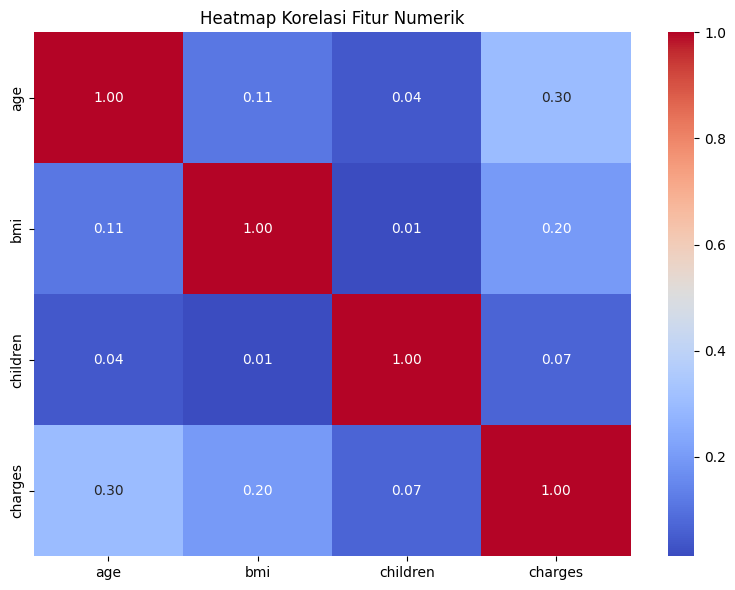

In [12]:
# Heatmap Korelasi
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [13]:
numeric_features     = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

numeric_transformer     = Pipeline([('scaler', MinMaxScaler())])
categorical_transformer = Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X = df.drop(columns=['charges'])
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_p = preprocessor.fit_transform(X_train)
X_test_p  = preprocessor.transform(X_test)

print(f'X_train: {X_train_p.shape}')
print(f'X_test : {X_test_p.shape}')

X_train: (1070, 11)
X_test : (268, 11)


In [14]:
# Simpan hasil preprocessing
os.makedirs('insurance_preprocessing', exist_ok=True)

train_df = pd.DataFrame(X_train_p).assign(target=y_train.reset_index(drop=True))
test_df  = pd.DataFrame(X_test_p).assign(target=y_test.reset_index(drop=True))

train_df.to_csv('insurance_preprocessing/insurance_train_preprocessed.csv', index=False)
test_df.to_csv('insurance_preprocessing/insurance_test_preprocessed.csv',  index=False)
dump(preprocessor, 'preprocessor.joblib')

print(f'Train: {train_df.shape}')
print(f'Test : {test_df.shape}')
print('Preprocessing selesai! File tersimpan di Google Drive.')

Train: (1070, 12)
Test : (268, 12)
Preprocessing selesai! File tersimpan di Google Drive.
